# 🖼️ Generating Figure 10

The following code generates Figure 10 of the paper plotting the results of Table 1.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

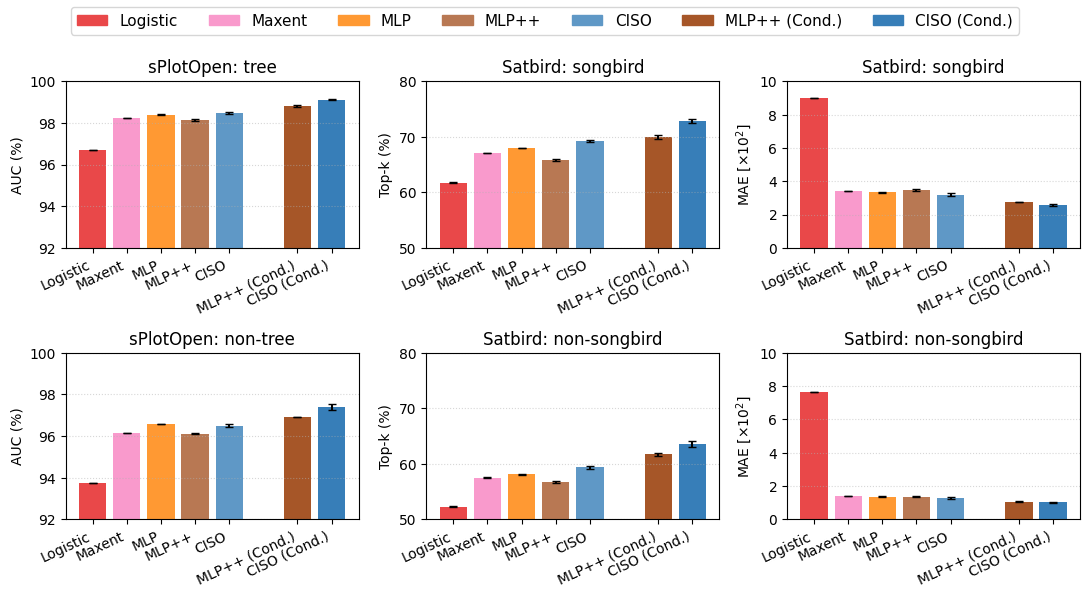

In [ ]:
models_uncond = ["Logistic", "Maxent", "MLP", "MLP++", "CISO"]
models_cond   = ["MLP++ (Cond.)", "CISO (Cond.)"]

means = {
    "AUC sPlotOpen: tree":           np.array([96.69, 98.24, 98.39, 98.15, 98.49, 98.82, 99.12]),
    "AUC sPlotOpen: non-tree":       np.array([93.74, 96.17, 96.58, 96.11, 96.49, 96.92, 97.39]),
    "Top-k Satbird: songbird":     np.array([61.75, 67.08, 67.99, 65.81, 69.30, 69.98, 72.86]),
    "Top-k Satbird: non-songbird": np.array([52.26, 57.52, 58.15, 56.76, 59.41, 61.76, 63.56]),
    "MAE Satbird: songbird":       np.array([8.99, 3.43, 3.34, 3.49, 3.19, 2.75, 2.57]),
    "MAE Satbird: non-songbird":   np.array([7.66, 1.39, 1.37, 1.37, 1.28, 1.06, 1.04]),
}

stds = {
    "AUC sPlotOpen: tree":           np.array([0.01, 0.00, 0.03, 0.04, 0.05, 0.03, 0.04]),
    "AUC sPlotOpen: non-tree":       np.array([0.00, 0.00, 0.01, 0.03, 0.07, 0.02, 0.14]),
    "Top-k Satbird: songbird":     np.array([0.04, 0.02, 0.04, 0.19, 0.21, 0.30, 0.37]),
    "Top-k Satbird: non-songbird": np.array([0.08, 0.04, 0.09, 0.14, 0.25, 0.27, 0.49]),
    "MAE Satbird: songbird":       np.array([0.02, 0.01, 0.02, 0.06, 0.09, 0.02, 0.08]),
    "MAE Satbird: non-songbird":   np.array([0.01, 0.01, 0.01, 0.03, 0.04, 0.02, 0.03]),
}


n_uncond = len(models_uncond)
n_cond = len(models_cond)

gap = 1.0
x_uncond = np.arange(n_uncond)
x_cond = np.arange(n_cond) + n_uncond + gap
x_all = np.concatenate([x_uncond, x_cond])

model_labels = models_uncond + models_cond

colors_indices = [0, 7, 4, 6, 1]
base_colors = plt.cm.Set1(colors_indices[:n_uncond])

def lighten(c, factor=0.5):
    return c + (1 - c) * factor

colors_uncond = np.array([lighten(c, 0.2) for c in base_colors])
colors_cond = base_colors[-n_cond:]

ordered_tasks = [
    "AUC sPlotOpen: tree", "Top-k Satbird: songbird", "MAE Satbird: songbird", 
    "AUC sPlotOpen: non-tree",  "Top-k Satbird: non-songbird", "MAE Satbird: non-songbird",  
]

fig, axes = plt.subplots(2, 3, figsize=(11, 6))
axes = axes.flatten()

for ax, task in zip(axes, ordered_tasks):
    mean = means[task]
    std  = stds[task]

    # Unconditioned bars
    for i in range(n_uncond):
        ax.bar(x_uncond[i], mean[i],
               yerr=std[i], color=colors_uncond[i], capsize=3)

    # Conditional bars
    for j in range(n_cond):
        ax.bar(x_cond[j], mean[n_uncond + j],
               yerr=std[n_uncond + j], color=colors_cond[j], capsize=3)

    # Formatting
    ax.set_title(' '.join(task.split(' ')[1:]))
    ax.set_xticks(x_all)
    ax.set_xticklabels(model_labels, rotation=25, ha="right")
    ax.grid(axis="y", linestyle=":", alpha=0.5)

    # y-limits / labels
    if "MAE" in task:
        ax.set_ylabel(r"MAE [$\times 10^{2}$]")
        ax.set_ylim(0, 10)
    elif "AUC" in task:
        ax.set_ylabel("AUC (%)")
        ax.set_ylim(92, 100)
    elif "Top-k" in task:
        ax.set_ylabel("Top-k (%)")
        ax.set_ylim(50, 80)

# Legend
legend_handles = []
legend_labels  = []

for name, color in zip(models_uncond, colors_uncond):
    legend_handles.append(plt.Rectangle((0,0),1,1,color=color))
    legend_labels.append(name)

for name, color in zip(models_cond, colors_cond):
    legend_handles.append(plt.Rectangle((0,0),1,1,color=color))
    legend_labels.append(name)

fig.legend(legend_handles, legend_labels,
           loc="upper center", ncol=7, fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("figure_results.pdf")
plt.show()
